# M8.3D — Head expressiveness

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Not in Final Report.**

**Conclusion:** Retain **Fourier-base + MLP head** as primary after comparing linear vs MLP on the interpretive triad.

Results CSVs: `checkpoints/m8/m08_3d_head_expressiveness/`.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = False
RUN_STUDY = True  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [4]:
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    load_m8_catalog_rows,
    load_win3d_results,
    plot_win3d_results,
    run_win3d_head_expressiveness_study,
    summarize_win3d,
    win3d_results_dir,
    win3d_task_specs,
    win3_grids_summary,
)

results_dir = win3d_results_dir(ROOT)
print(f"results_dir={display_path(results_dir)}")


results_dir=checkpoints/m8/m08_3d_head_expressiveness


## Milestone 8 Step 3D predefined grid

In [5]:
display(win3_grids_summary()['3D_head_expressiveness'])


,arch_name,head_type,encoder_channels,downsample,maxpool_after_blocks,pool_schedule,pre_flatten_channels,embed_dim,flatten_hidden,flatten_head,input_representation,normalisation
0,pooled_base_base,pooled,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,128,mlp,anomaly_ref,none
1,fourier_base_linear,fourier,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,1,linear,anomaly_ref,none
2,fourier_base_mlp,fourier,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,128,mlp,anomaly_ref,none
3,flatten_base_linear,flatten,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,1,linear,anomaly_ref,none
4,flatten_base_mlp,flatten,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,128,mlp,anomaly_ref,none


## Contract test

In [6]:
run_installed_pytest_test(m8_validation, "test_m8_3d_head_expressiveness_grid_nonempty")


M8.3D
Test executed: test_m8_3d_head_expressiveness_grid_nonempty()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.73s ===============================

Test proves: Milestone 8 Step 3D head grid compares linear vs MLP on the triad.


## Train / validation study

In [7]:
rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
train_task, val_task, _ = win3d_task_specs()
train_ds = build_task_dataset(rows, train_task)
val_ds = build_task_dataset(rows, val_task)

summary_df, runs_df = load_win3d_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else (runs_df is None or runs_df.empty)
if should_run:
    summary_df, runs_df, _ = run_win3d_head_expressiveness_study(
        train_ds, val_ds, train_task,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
else:
    print("Loaded existing runs CSV — set RUN_STUDY=True to retrain.")
display(summary_df)



######## Milestone 8 Step 3D repeat 1/5  seed=5 ########
  pooled_base_base rep 1 epoch 001/200  train_loss=38.31787  val_RMSE=5.6651  best=5.6651*  stall=0/40
  pooled_base_base rep 1 epoch 002/200  train_loss=32.91303  val_RMSE=5.3590  best=5.3590*  stall=0/40
  pooled_base_base rep 1 epoch 003/200  train_loss=30.06536  val_RMSE=5.1522  best=5.1522*  stall=0/40
  pooled_base_base rep 1 epoch 004/200  train_loss=29.06862  val_RMSE=5.1027  best=5.1027*  stall=0/40
  pooled_base_base rep 1 epoch 005/200  train_loss=28.73828  val_RMSE=5.0393  best=5.0393*  stall=0/40
  pooled_base_base rep 1 epoch 006/200  train_loss=28.13534  val_RMSE=4.9848  best=4.9848*  stall=0/40
  pooled_base_base rep 1 epoch 007/200  train_loss=27.84133  val_RMSE=4.9811  best=4.9811*  stall=0/40
  pooled_base_base rep 1 epoch 008/200  train_loss=27.64316  val_RMSE=4.9564  best=4.9564*  stall=0/40
  pooled_base_base rep 1 epoch 009/200  train_loss=27.52542  val_RMSE=4.9436  best=4.9436*  stall=0/40
  pooled_base_b

,experiment_id,win,architecture_factor,hypothesis,head_type,downsample,encoder_channels,architecture_config,parameter_count,feature_map_hw,...,interpretation,train_RMSE_total_mean,train_RMSE_total_std,validation_RMSE_total_mean,validation_RMSE_total_std,best_validation_RMSE_total_mean,best_validation_RMSE_total_std,variant,n_repeat,seeds
4,win3d__flatten_base_mlp,3D,head_expressiveness,mlp_head_needed_on_frozen_fourier_primary,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,"(128, 128)",...,,0.783694,0.252752,1.571745,0.165347,1.571745,0.165347,flatten_base_mlp,5,"5,6,7,8,9"
3,win3d__flatten_base_linear,3D,head_expressiveness,mlp_head_needed_on_frozen_fourier_primary,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_linear"", ""head_typ...",3177347,"(128, 128)",...,,0.930760,0.243996,1.620152,0.133555,1.620152,0.133555,flatten_base_linear,5,"5,6,7,8,9"
1,win3d__fourier_base_linear,3D,head_expressiveness,mlp_head_needed_on_frozen_fourier_primary,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_linear"", ""head_typ...",31811,"(128, 128)",...,,1.232572,0.116311,1.620600,0.096408,1.620600,0.096408,fourier_base_linear,5,"5,6,7,8,9"
2,win3d__fourier_base_mlp,3D,head_expressiveness,mlp_head_needed_on_frozen_fourier_primary,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,"(128, 128)",...,,1.042141,0.260220,1.681392,0.166269,1.681392,0.166269,fourier_base_mlp,5,"5,6,7,8,9"
0,win3d__pooled_base_base,3D,head_expressiveness,mlp_head_needed_on_frozen_fourier_primary,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,"(128, 128)",...,,2.913859,0.104322,3.108310,0.150530,3.108310,0.150530,pooled_base_base,5,"5,6,7,8,9"


## Results

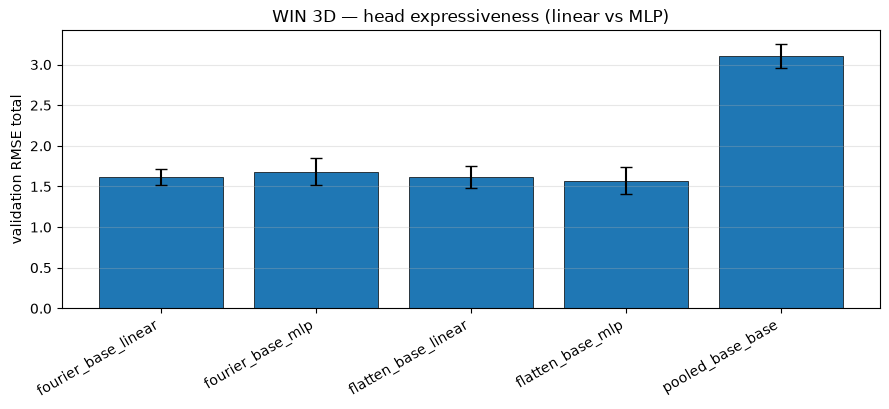

- Fourier primary: linear=1.621, MLP=1.681 (Δ=+0.061). MLP retained for freeze.

- Formal architecture freeze follows in Milestone 8 Step 3E — do not reopen head search in M9.

In [8]:
fig = plot_win3d_results(summary_df)
plt.show()
for line in summarize_win3d(summary_df):
    display(Markdown(f"- {line}"))
